<a href="https://colab.research.google.com/github/szabeebzaliz7-a11y/Datascience-And-Gen-AI/blob/main/Assignment_09_CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building a CNN Model for Image Classification

Objective

The goal of this assignment is to design, implement, and evaluate a Convolutional Neural
Network (CNN) model using a real-world dataset. Students will gain hands-on experience in
data preprocessing, CNN architecture design, training, evaluation, and model interpretation.

Dataset

Use the Intel Image Classification Dataset (available on Kaggle).
● Link: Intel Image Classification
● It contains 25,000+ natural scene images across 6 classes:
○ Buildings
○ Forest
○ Glacier
○ Mountain
○ Sea
○ Street

Tasks

Part A: Data Understanding and Preprocessing
1. Load the dataset and explore its structure (number of classes, sample images, image
sizes).
2. Perform data preprocessing steps:

○ Resize all images to a common size (e.g., 150×150).
○ Normalize pixel values.
○ Split dataset into train, validation, and test sets.
○ Apply data augmentation (rotation, flip, zoom, shift, etc.) to improve
generalization.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras import layers,models



# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [2]:
os.listdir(path)


['seg_train', 'seg_pred', 'seg_test']

In [3]:
data_path=os.path.join(path,'seg_train', 'seg_pred', 'seg_test')
print(data_path)

/kaggle/input/intel-image-classification/seg_train/seg_pred/seg_test


In [4]:
train_path=os.path.join(path,'seg_train','seg_train')
test_path=os.path.join(path,'seg_test','seg_test')
pred_path=os.path.join(path,'seg_pred')
print(train_path)
print(test_path)
print(pred_path)

/kaggle/input/intel-image-classification/seg_train/seg_train
/kaggle/input/intel-image-classification/seg_test/seg_test
/kaggle/input/intel-image-classification/seg_pred


In [5]:
#Data Preprocessing

train_ds=tf.keras.utils.image_dataset_from_directory(
    train_path,
    shuffle=True,
    image_size=(150,150),
    batch_size=32
)
test_ds=tf.keras.utils.image_dataset_from_directory(
    test_path,
    shuffle=True,
    image_size=(150,150),
    batch_size=32
)
pred_ds=tf.keras.utils.image_dataset_from_directory(
    pred_path,
    shuffle=True,
    image_size=(150,150),
    batch_size=32
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Found 7301 files belonging to 1 classes.


In [6]:
class_names=train_ds.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


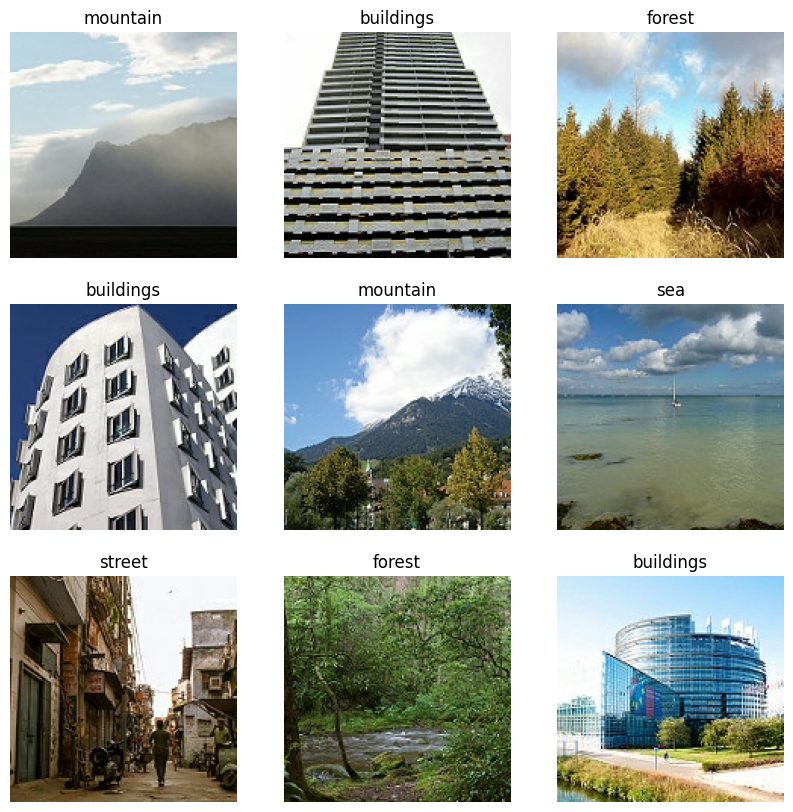

In [7]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in train_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [8]:
#Data Augmentation

data_augmentation=tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
    ]
)

Part B: CNN Model Development

3. Build a Convolutional Neural Network (CNN) from scratch using TensorFlow/Keras or
PyTorch.
○ Minimum 3 convolutional layers.
○ Use activation functions (ReLU, softmax).
○ Apply pooling layers (max pooling/average pooling).
○ Add fully connected layers and dropout for regularization.
4. Train the CNN model on the training dataset and validate it on the validation set.
○ Plot training vs. validation loss and accuracy curves.
○ Use early stopping and model checkpointing if necessary.

In [9]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.5),

    layers.Flatten(),

    layers.Dense(512,activation='relu'),
    layers.Dense(6,activation='softmax')
])

model.build(input_shape=(None,150,150,3))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,742 (72.62 MB)

 Trainable params: 19,036,742 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.0001
)
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)


In [12]:
history=model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2966 - loss: 36.2506

439/439 ━━━━━━━━━━━━━━━━━━━━ 46s 90ms/step - accuracy: 0.3680 - loss: 8.1967 - val_accuracy: 0.4913 - val_loss: 1.2744
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.5120 - loss: 1.2263 - val_accuracy: 0.4497 - val_loss: 1.4605
Epoch 3/20
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5417 - loss: 1.1343

439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.5542 - loss: 1.0998 - val_accuracy: 0.5410 - val_loss: 1.1077
Epoch 4/20
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5716 - loss: 1.0593

439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.5808 - loss: 1.0348 - val_accuracy: 0.5737 - val_loss: 1.0561
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.5870 - loss: 1.0274 - val_accuracy: 0.5673 - val_loss: 1.0500
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.6149 - loss: 0.9481 - val_accuracy: 0.5343 - val_loss: 1.1177
Epoch 7/20
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6145 - loss: 0.9377

439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.6211 - loss: 0.9306 - val_accuracy: 0.5977 - val_loss: 0.9948
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.6366 - loss: 0.9028 - val_accuracy: 0.5163 - val_loss: 1.2005
Epoch 9/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.6539 - loss: 0.8540 - val_accuracy: 0.5717 - val_loss: 1.0440
Epoch 10/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6851 - loss: 0.7898 - val_accuracy: 0.5853 - val_loss: 1.0741
Epoch 11/20
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6966 - loss: 0.7725

439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.6981 - loss: 0.7763 - val_accuracy: 0.6573 - val_loss: 0.9390
Epoch 12/20
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7222 - loss: 0.7218

439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.7315 - loss: 0.6912 - val_accuracy: 0.6767 - val_loss: 0.9493
Epoch 13/20
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7615 - loss: 0.6270

439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.7628 - loss: 0.6261 - val_accuracy: 0.7223 - val_loss: 0.9524
Epoch 14/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7832 - loss: 0.5943 - val_accuracy: 0.6533 - val_loss: 0.9988
Epoch 15/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8133 - loss: 0.5070 - val_accuracy: 0.6313 - val_loss: 1.1255
Epoch 16/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8376 - loss: 0.4448 - val_accuracy: 0.7190 - val_loss: 0.9311
Epoch 17/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8591 - loss: 0.3986 - val_accuracy: 0.7060 - val_loss: 1.0539
Epoch 18/20
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8593 - loss: 0.4079

439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8645 - loss: 0.3870 - val_accuracy: 0.7520 - val_loss: 0.9404
Epoch 19/20
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8748 - loss: 0.3636

439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8856 - loss: 0.3306 - val_accuracy: 0.7523 - val_loss: 0.9863
Epoch 20/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8962 - loss: 0.3020 - val_accuracy: 0.7317 - val_loss: 1.0691


In [13]:

scores=model.evaluate(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7190 - loss: 0.9311


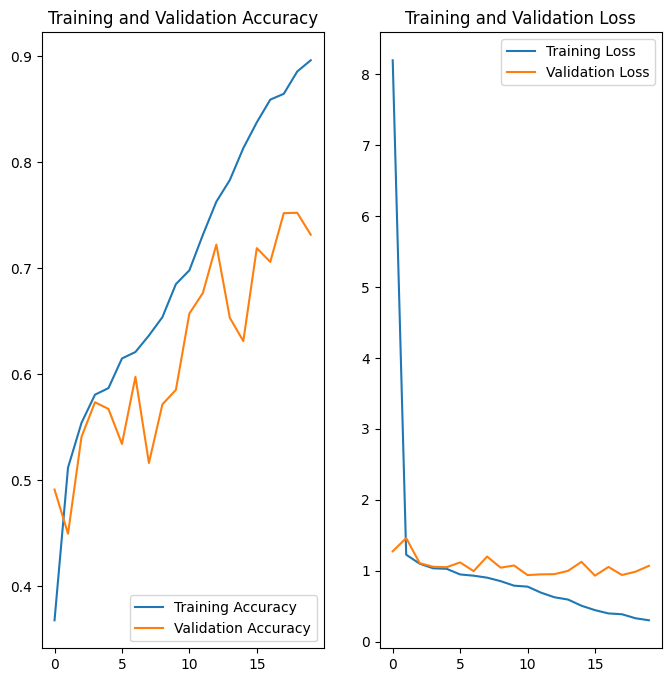

In [14]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range=range(len(acc))

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training Accuracy')
plt.plot(epochs_range,val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training Loss')
plt.plot(epochs_range,val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Part C: Model Evaluation and Interpretation

5. Evaluate the model on the test set and report performance metrics:
○ Accuracy
○ Precision, Recall, F1-score per class
○ Confusion Matrix
6. Visualize predictions for at least 10 random test images with predicted vs. actual labels.

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels from the test dataset
true_labels = []
for _, labels in test_ds:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)

# Get predictions from the model on the test dataset
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


In [17]:
print('Classification Report:')
print(classification_report(true_labels, predicted_labels, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

   buildings       0.15      0.11      0.13       437
      forest       0.15      0.16      0.15       474
     glacier       0.16      0.12      0.14       553
    mountain       0.18      0.25      0.21       525
         sea       0.15      0.12      0.13       510
      street       0.16      0.20      0.18       501

    accuracy                           0.16      3000
   macro avg       0.16      0.16      0.16      3000
weighted avg       0.16      0.16      0.16      3000



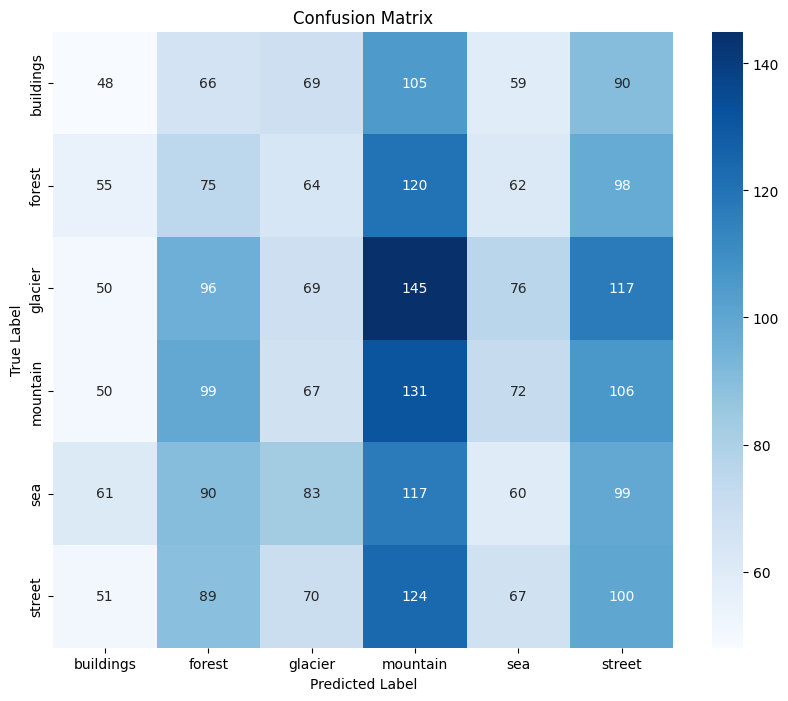

In [18]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


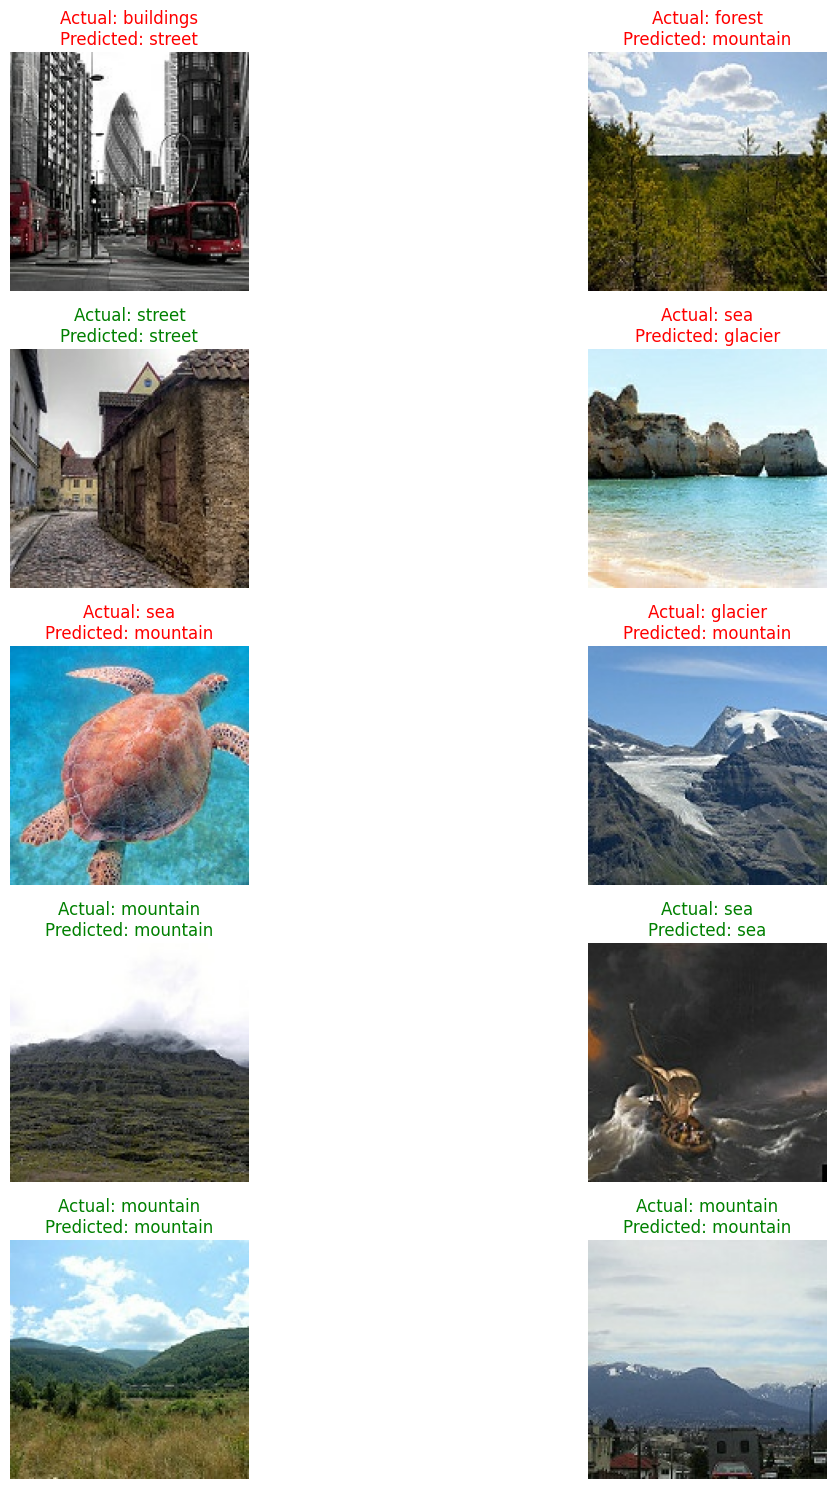

In [19]:
import random

plt.figure(figsize=(15, 15))

# Get a batch of images and labels from the test dataset
for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    # Select 10 random indices from the batch
    random_indices = random.sample(range(len(images)), min(10, len(images)))

    for i, idx in enumerate(random_indices):
        ax = plt.subplot(5, 2, i + 1) # Adjust subplot grid for 10 images
        plt.imshow(images[idx].numpy().astype("uint8"))
        actual_label = class_names[labels[idx]]
        predicted_label = class_names[predicted_classes[idx]]
        title_color = "green" if actual_label == predicted_label else "red"
        plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}", color=title_color)
        plt.axis("off")
plt.tight_layout()
plt.show()